In [1]:
import pyreadr
import torch

from src.gaussian_mixture import GaussianMixtureMAR
from src.metrics import energy_distance_faster

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Load dataset.

In [2]:
datasets = ["parkinsons", "allergens", "concrete", "windspeed", "forest", "housing", "stock", "pumadyn32nm", "scm20d", "scm1d"]

In [3]:
def run_realdata(
        i, # dataset index
        B=50, # number of MC
        k_range=(1,500), # ks to choose from
        crit='bic', # criterion for choosing k
        ct='diag', # covariance structure
        n_inits=20 # number of inits
        ):
    print(datasets[i])
    Xstar_df = pyreadr.read_r(f"datasets/split_test/test.{datasets[i]}.RDS")[None]
    X_miss_df = pyreadr.read_r(f"datasets/split_amputed/mar.{datasets[i]}.RDS")[None]
    # Prepare the data
    Xm = torch.tensor(X_miss_df.values, dtype=torch.float64)
    X = torch.nan_to_num(Xm, nan=0.0) # input to GMM
    Xstar = torch.tensor(Xstar_df.values)
    M_np = (X_miss_df.notna()).astype(int).values
    M = torch.tensor(M_np, dtype=torch.float64)
    n_samples = X.shape[0]
    gmm = GaussianMixtureMAR(
                k_range=k_range, 
                criterion=crit,
                cov_type=ct, 
                n_init=n_inits
            )
    gmm.fit(X, M)
    ed_scaled = [energy_distance_faster(Xstar, gmm.sample(n_samples)[0], scale=True) for _ in range(B)]
    return ed_scaled

In [4]:
# res = np.array(
#     [run_realdata(i) for i in range(len(datasets))]
# )

In [5]:
res = np.load('realdata_results.npy')

In [6]:
means = res.mean(axis=1)
vars = res.std(axis=1)
res_df = pd.DataFrame({datasets[i]:[round(means[i].tolist(),2), round(vars[i].tolist(),2)] for i in range(10)}, index=['mean', 'std'])

In [7]:
cols = ['scm1d', 'scm20d', 'pumadyn32nm', 'parkinsons', 'allergens', 'concrete', 'stock', 'forest', 'housing', 'windspeed']
res_df[cols].T

,mean,std
scm1d,75.04,5.14
scm20d,46.76,4.54
pumadyn32nm,11.92,1.26
parkinsons,14245.72,328.30
allergens,40.67,8.25
concrete,7.60,1.47
stock,7.78,2.15
forest,5.51,1.30
housing,9.66,3.19
windspeed,3.43,0.82


parkinsons
  k=192 -> score=-68737.7578
  k=309 -> score=-68759.0156
  k=382 -> score=-67937.2109
  k=265 -> score=-68875.8828
  k=237 -> score=-68790.9141
  k=281 -> score=-68556.6484
  k=254 -> score=-68657.8516
  k=271 -> score=-68971.9922
  k=275 -> score=-68625.9844
  k=269 -> score=-68273.2812
  k=273 -> score=-68876.1094
  k=272 -> score=-68330.9922


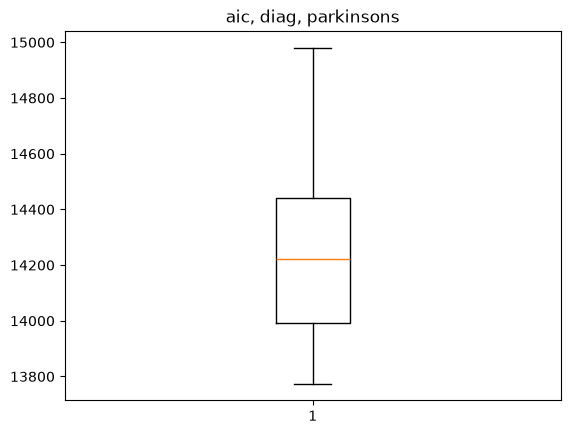

In [9]:
crit = 'aic'
ct = 'diag'

ed_parkisons = run_realdata(
    i=0,
    crit=crit,
    ct=ct
)

plt.boxplot(ed_parkisons)
plt.title(f'{crit}, {ct}, parkinsons')
plt.show()